## README

Sections:
- CROSS VALIDATION: A cross validated grid search for the best preprocessing strategy + model architecture + model hyperparameters
- USAGE: How to load in the model and use it for inference

# CROSS VALIDATION

In [2]:
# NOTE: Run in the ml_model directory

# Import helpers
import sys
import os
sys.path.append(os.path.join(os.path.dirname('.'), '..'))

# Preprocessing
from processing.preprocess_pipeline import (
    MNEPipeline, notch, bandpass, rereference,
    add_idle_class, epoch, extract_tensor, extract_pca, extract_bandpower, extract_raw, extract_cwt, extract_csp
)
import numpy as np
import json
import itertools
from torch.utils.data import DataLoader, TensorDataset, Subset
from sklearn.model_selection import StratifiedKFold

# Importing models
from models import (
    DeepConvNet, ShallowConvNet, EEGNet, ATCNet, Conformer, CTNet, MBMANet, PBT, LMDANet, EEGITNet
)

import torch
import torch.nn as nn

In [ ]:
# =============================================================================
# Configurations
# =============================================================================

N_CHANNELS   = 8    # Number of EEG channels in your data
N_CLASSES    = 3    # idle, move, jaw_clench
SFREQ        = 300  # Sample rate
TRIAL_DUR    = 3.0  # seconds (tmax - tmin in epoch())
N_TIMEPOINTS = int(SFREQ * TRIAL_DUR)

FILES = [
    '../data_collection/annotated_eeg/chengyi_4_8_0.fif',
    '../data_collection/annotated_eeg/chengyi_4_8_1.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_0.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_1.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_2.fif',
]
LABEL_MAP = {'idle': 0, 'move': 1, 'jaw_clench': 2}
MAP_LABEL = {v: k for k, v in LABEL_MAP.items()}

EPOCHS = 500
BATCH_SIZE = 32
CV_FOLDS   = 5
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Directory where trained models will be saved
SAVE_DIR = './best_models'

print(f"Device: {DEVICE}  |  N_CHANNELS: {N_CHANNELS}  |  N_TIMEPOINTS: {N_TIMEPOINTS}")

Device: cuda  |  N_CHANNELS: 8  |  N_TIMEPOINTS: 900


In [ ]:
# =============================================================================
# Hyperparameter grid
# =============================================================================

BANDPASS_CONFIGS = [
    [(8, 13)],
    [(13, 30)],
    [(8, 13), (13, 30)],
    [(4, 8), (8, 13), (13, 30)],
]
EXTRACTORS = [
    extract_tensor(), 
    extract_pca(), 
    extract_bandpower(), 
    extract_raw(), 
    extract_csp(),
    # extract_cwt(), 
]
LRS    = [1e-5, 1e-4, 1e-3]
MODEL_REGISTRY = {
    'DeepConvNet'  : lambda: DeepConvNet(N_CHANNELS, N_CLASSES),
    'ShallowConvNet': lambda: ShallowConvNet(N_CHANNELS, N_CLASSES),
    'EEGNet'       : lambda: EEGNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    'ATCNet'       : lambda: ATCNet(N_CHANNELS, N_CLASSES, SFREQ),
    'Conformer'    : lambda: Conformer(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    'CTNet'        : lambda: CTNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    'MBMANet'      : lambda: MBMANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS, SFREQ),
    'LMDANet'      : lambda: LMDANet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
    'EEGITNet'     : lambda: EEGITNet(N_CHANNELS, N_CLASSES, N_TIMEPOINTS),
}
GRID = list(itertools.product(BANDPASS_CONFIGS, EXTRACTORS, LRS, MODEL_REGISTRY.keys()))

In [ ]:
# =============================================================================
# Load data
# =============================================================================

def load_data(files, bands, label_map, extractor):
    all_X, all_y = [], []
    for file in files:
        pipeline = MNEPipeline(file)
        pipeline.add(notch(60))
        pipeline.add(bandpass(bands))
        pipeline.add(rereference())
        pipeline.add(add_idle_class(window_dur=3.0, idle_start_min=1.0))
        pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))

        raw = pipeline.run()
        X, y = extractor(raw)

        auto_ids = raw._event_id
        remap = {v: label_map[k] for k, v in auto_ids.items() if k in label_map}
        y = np.array([remap[yi] for yi in y])

        T = X.shape[-1]
        if T > N_TIMEPOINTS:
            X = X[..., :N_TIMEPOINTS]
        elif T < N_TIMEPOINTS:
            pad = np.zeros((*X.shape[:-1], N_TIMEPOINTS - T), dtype=np.float32)
            X = np.concatenate([X, pad], axis=-1)

        all_X.append(X)
        all_y.append(y)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)

    # Show class distribution
    unique, counts = np.unique(y, return_counts=True)
    print("Class distribution:")
    for cls, count in zip(unique, counts):
        print(f"  Class {MAP_LABEL[cls]}: {count} samples")

    # Balance classes to the size of the smallest class
    min_count = counts.min()
    balanced_indices = np.concatenate([
        np.random.choice(np.where(y == cls)[0], size=min_count, replace=False)
        for cls in unique
    ])

    np.random.shuffle(balanced_indices)
    X, y = X[balanced_indices], y[balanced_indices]

    print(f"\nAfter balancing (min={min_count} per class):")
    for cls, count in zip(*np.unique(y, return_counts=True)):
        print(f"  Class {MAP_LABEL[cls]}: {count} samples")

    print(f"  Loaded: X={X.shape}, classes={np.unique(y, return_counts=True)}")
    return X, y

# X, y = load_data(FILES, BANDPASS_CONFIGS[0], LABEL_MAP, EXTRACTORS[0]) # Loaded: X=(970, 1, 8, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))
# X, y = load_data(FILES, BANDPASS_CONFIGS[0], LABEL_MAP, EXTRACTORS[1]) # Loaded: X=(970, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))
# X, y = load_data(FILES, BANDPASS_CONFIGS[0], LABEL_MAP, EXTRACTORS[2]) # Loaded: X=(970, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))
# X, y = load_data(FILES, BANDPASS_CONFIGS[0], LABEL_MAP, EXTRACTORS[3]) # Loaded: X=(970, 8, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))
# X, y = load_data(FILES, BANDPASS_CONFIGS[0], LABEL_MAP, EXTRACTORS[4]) # Loaded: X=(970, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))

In [5]:
# =============================================================================
# Training utilities
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(yb)
        correct   += (out.argmax(1) == yb).sum().item()
        n         += len(yb)
    return total_loss / n, correct / n


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        out = model(xb)
        loss = criterion(out, yb)
        total_loss += loss.item() * len(yb)
        correct   += (out.argmax(1) == yb).sum().item()
        n         += len(yb)
    return total_loss / n, correct / n


def run_cv(model_fn, X, y, config):
    """
    model_fn : callable with no args → returns a fresh model
    config   : dict with keys epochs, batch_size, lr, cv_folds, device, patience

    Returns
    -------
    fold_results : list of dicts with val_acc, val_loss, model per fold
    best_model   : the model instance from the fold with the highest val_acc
    """
    device    = config['device']
    criterion = nn.CrossEntropyLoss()
    skf       = StratifiedKFold(n_splits=config['cv_folds'], shuffle=True, random_state=42)

    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    dataset = TensorDataset(Xt, yt)

    fold_results = []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n── Fold {fold+1}/{config['cv_folds']} ──")

        train_loader = DataLoader(Subset(dataset, train_idx),
                                  batch_size=config['batch_size'], shuffle=True)
        val_loader   = DataLoader(Subset(dataset, val_idx),
                                  batch_size=config['batch_size'])

        model     = model_fn().to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'])
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                        optimizer, T_max=config['epochs'])

        best_val_loss  = float('inf')
        best_state     = None
        patience_count = 0

        for epoch in range(1, config['epochs'] + 1):
            tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
            va_loss, va_acc = eval_epoch(model, val_loader, criterion, device)
            scheduler.step()

            if epoch % 10 == 0:
                print(f"  ep {epoch:3d} | tr {tr_loss:.4f}/{tr_acc:.3f} "
                      f"| va {va_loss:.4f}/{va_acc:.3f}")

            # Early stopping
            if va_loss < best_val_loss - 1e-4:
                best_val_loss  = va_loss
                best_state     = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                patience_count = 0
            else:
                patience_count += 1
                if patience_count >= config['patience']:
                    print(f"  Early stop at epoch {epoch}")
                    break

        model.load_state_dict(best_state)
        _, best_val_acc = eval_epoch(model, val_loader, criterion, device)
        fold_results.append({'val_acc': best_val_acc, 'val_loss': best_val_loss, 'model': model})
        print(f"  Best val acc: {best_val_acc:.4f}")

    accs = [r['val_acc'] for r in fold_results]
    print(f"\nCV result: {np.mean(accs):.4f} ± {np.std(accs):.4f}")

    # Pick the single best fold model to return for saving
    best_fold  = max(fold_results, key=lambda r: r['val_acc'])
    best_model = best_fold['model']

    return fold_results, best_model

In [ ]:
# =============================================================================
# Run all models
# =============================================================================

all_results  = []
for item in GRID: 
    
    bandpass_config, extractor, learning_rate, model_name = item
    print(f"\n{'='*50}\n{model_name}\n{'='*50}")
    config = {
        'epochs'     : EPOCHS,
        'batch_size' : BATCH_SIZE,
        'lr'         : learning_rate,
        'cv_folds'   : CV_FOLDS,
        'device'     : DEVICE,
        'patience'   : 15,          # stop if val loss doesn't improve for 15 epochs
    }
    X, y = load_data(FILES, bandpass_config, LABEL_MAP, extractor)

    try:
        fold_results, best_model = run_cv(MODEL_REGISTRY[model_name], X, y, config)

        save_results = {
            'bandpass_config': bandpass_config,
            'extractor': extractor,
            'learning_rate': learning_rate,
            'fold_results': fold_results,
            'best_model': best_model
        }
        
    except Exception as e:
        print(f"Couldn't train {item}")

        save_results = {
            'bandpass_config': bandpass_config,
            'extractor': extractor,
            'learning_rate': learning_rate,
            'fold_results': None,
            'best_model': None
        }
    
    all_results.append(save_results)
 

In [3]:
import dill

# dill.dump_session('models.db')
dill.load_session('models.db')

In [4]:
import pandas as pd
import numpy as np

results = pd.DataFrame(all_results)
results = results.dropna()

# Extract val_acc from each fold, then compute mean and std
results['val_accs']   = results['fold_results'].apply(lambda folds: [fold['val_acc'] for fold in folds])
results['mean_acc']   = results['val_accs'].apply(np.mean)
results['std_acc']    = results['val_accs'].apply(np.std)

In [11]:
results.sort_values(by=['mean_acc'], ascending=False).head(5)

,bandpass_config,extractor,learning_rate,fold_results,best_model,val_accs,mean_acc,std_acc
144,"[(13, 30)]",<function extract_tensor.<locals>.extract at 0...,0.0001,"[{'val_acc': 0.9259259259259259, 'val_loss': 0...",DeepConvNet(\n (max_pool): MaxPool2d(kernel_s...,"[0.9259259259259259, 0.9166666666666666, 0.953...",0.914815,0.024428
161,"[(13, 30)]",<function extract_tensor.<locals>.extract at 0...,0.0010,"[{'val_acc': 0.8888888888888888, 'val_loss': 0...",EEGITNet(\n (inception): Sequential(\n (0)...,"[0.8888888888888888, 0.8796296296296297, 0.916...",0.912963,0.029045
288,"[(8, 13), (13, 30)]",<function extract_tensor.<locals>.extract at 0...,0.0010,"[{'val_acc': 0.8981481481481481, 'val_loss': 0...",DeepConvNet(\n (max_pool): MaxPool2d(kernel_s...,"[0.8981481481481481, 0.9351851851851852, 0.898...",0.903704,0.016144
26,"[(8, 13)]",<function extract_tensor.<locals>.extract at 0...,0.0010,"[{'val_acc': 0.9074074074074074, 'val_loss': 0...",EEGITNet(\n (inception): Sequential(\n (0)...,"[0.9074074074074074, 0.8796296296296297, 0.935...",0.903704,0.029630
431,"[(4, 8), (8, 13), (13, 30)]",<function extract_tensor.<locals>.extract at 0...,0.0010,"[{'val_acc': 0.9444444444444444, 'val_loss': 0...",EEGITNet(\n (inception): Sequential(\n (0)...,"[0.9444444444444444, 0.8981481481481481, 0.916...",0.901852,0.037314


In [ ]:
# Loading in the best model to save (DeepConvNet with raw extractor and (13,30) bandpass filter)

best_result = results.sort_values(by=['mean_acc'], ascending=False).iloc[0]
bandpass_config = best_result['bandpass_config']
extractor = best_result['extractor']
best_model = best_result['best_model']

torch.save(best_model.state_dict(), 'DeepConvNet.pt')

In [27]:
bandpass_config

[(13, 30)]

In [28]:
extractor

<function processing.preprocess_pipeline.extract_tensor.<locals>.extract(raw: mne.io.fiff.raw.Raw)>

# Loading in the model

In [39]:
# Import helpers
import sys
import os
sys.path.append(os.path.join(os.path.dirname('.'), '..'))

# Preprocessing
from processing.preprocess_pipeline import (
    MNEPipeline, notch, bandpass, rereference, extract_tensor
)
import numpy as np
import json
import itertools
from torch.utils.data import DataLoader, TensorDataset, Subset

# Importing models
from models import DeepConvNet

import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    classification_report, cohen_kappa_score
)
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
# =============================================================================
# Configurations
# =============================================================================

N_CHANNELS   = 8    # Number of EEG channels in your data
N_CLASSES    = 3    # idle, move, jaw_clench
SFREQ        = 300  # Sample rate
TRIAL_DUR    = 3.0  # seconds (tmax - tmin in epoch())
N_TIMEPOINTS = int(SFREQ * TRIAL_DUR)

FILES = [
    '../data_collection/annotated_eeg/chengyi_4_8_0.fif',
    '../data_collection/annotated_eeg/chengyi_4_8_1.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_0.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_1.fif',
    '../data_collection/annotated_eeg/chengyi_4_9_2.fif',
]
LABEL_MAP = {'idle': 0, 'move': 1, 'jaw_clench': 2}
MAP_LABEL = {v: k for k, v in LABEL_MAP.items()}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}  |  N_CHANNELS: {N_CHANNELS}  |  N_TIMEPOINTS: {N_TIMEPOINTS}")


BANDPASS_CONFIG = [(13, 30)]
EXTRACTOR = extract_tensor()
MODEL = DeepConvNet(N_CHANNELS, N_CLASSES).to(DEVICE)
MODEL.load_state_dict(torch.load('DeepConvNet.pt'))

# =============================================================================
# Load data
# =============================================================================

def load_data(files, bands, label_map, extractor, balance=False):
    all_X, all_y = [], []
    for file in files:
        pipeline = MNEPipeline(file)
        pipeline.add(notch(60))
        pipeline.add(bandpass(bands))
        pipeline.add(rereference())
        pipeline.add(add_idle_class(window_dur=3.0, idle_start_min=1.0))
        pipeline.add(epoch(tmin=0, tmax=TRIAL_DUR))

        raw = pipeline.run()
        X, y = extractor(raw)

        auto_ids = raw._event_id
        remap = {v: label_map[k] for k, v in auto_ids.items() if k in label_map}
        y = np.array([remap[yi] for yi in y])

        T = X.shape[-1]
        if T > N_TIMEPOINTS:
            X = X[..., :N_TIMEPOINTS]
        elif T < N_TIMEPOINTS:
            pad = np.zeros((*X.shape[:-1], N_TIMEPOINTS - T), dtype=np.float32)
            X = np.concatenate([X, pad], axis=-1)

        all_X.append(X)
        all_y.append(y)

    X = np.concatenate(all_X, axis=0)
    y = np.concatenate(all_y, axis=0)

    # Show class distribution
    unique, counts = np.unique(y, return_counts=True)
    print("Class distribution:")
    for cls, count in zip(unique, counts):
        print(f"  Class {MAP_LABEL[cls]}: {count} samples")

    # Balance classes to the size of the smallest class
    if balance:
        min_count = counts.min()
        balanced_indices = np.concatenate([
            np.random.choice(np.where(y == cls)[0], size=min_count, replace=False)
            for cls in unique
        ])

        np.random.shuffle(balanced_indices)
        X, y = X[balanced_indices], y[balanced_indices]

        print(f"\nAfter balancing (min={min_count} per class):")
        for cls, count in zip(*np.unique(y, return_counts=True)):
            print(f"  Class {MAP_LABEL[cls]}: {count} samples")

    print(f"  Loaded: X={X.shape}, classes={np.unique(y, return_counts=True)}")
    return X, y

X, y = load_data(FILES, BANDPASS_CONFIG, LABEL_MAP, EXTRACTOR)

# =============================================================================
# Inference
# =============================================================================

@torch.no_grad()
def inference(model, x, device):
    model.eval()
    x = torch.tensor(x, dtype=torch.float32).to(device)  # numpy → tensor
    x = x.unsqueeze(0)
    out = model(x)
    return out

index_to_try = 0

out = inference(model=MODEL, x=X[index_to_try], device=DEVICE)
predicted_index = out.argmax(dim=1).item()
predicted_label = MAP_LABEL[predicted_index]
print("Predicted:", predicted_label)
print("Ground:", y[index_to_try])


Device: cuda  |  N_CHANNELS: 8  |  N_TIMEPOINTS: 900
Opening raw data file ../data_collection/annotated_eeg/chengyi_4_8_0.fif...
Isotrak not found
    Range : 0 ... 287999 =      0.000 ...   959.997 secs
Ready.
Reading 0 ... 287999  =      0.000 ...   959.997 secs...
Applying: <function notch.<locals>.apply at 0x76c4e0f66200>
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Applying: <function bandpass.<locals>.apply at 0x76c4e0fdefc0>
Filtering raw data in 1 contiguous segment
Se

Applying: <function rereference.<locals>.apply at 0x76c4e0fdf600>
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


/home/chengyi/Projects/Weimo/ml_model/../processing/preprocess_pipeline.py:307: RuntimeWarning: This filename (../data_collection/annotated_eeg/chengyi_4_8_0.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


Applying: <function add_idle_class.<locals>.apply at 0x76c4e0fdd300>
[idle] Added 131 idle windows  |  label: 'idle'
Applying: <function epoch.<locals>.apply at 0x76c4e0fde0c0>
Used Annotations descriptions: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
Not setting metadata
205 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 205 events and 901 original time points ...
0 bad epochs dropped
Epoched: 205 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
[Tensor] shape: (205, 1, 8, 901)
Opening raw data file ../data_collection/annotated_eeg/chengyi_4_8_1.fif...
Isotrak not found
    Range : 0 ... 271799 =      0.000 ...   905.997 secs
Ready.
Reading 0 ... 271799  =      0.000 ...   905.997 secs...
Applying: <function notch.<locals>.apply at 0x76c4e0f66200>
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
-------------------

/home/chengyi/Projects/Weimo/ml_model/../processing/preprocess_pipeline.py:307: RuntimeWarning: This filename (../data_collection/annotated_eeg/chengyi_4_8_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


...

0 bad epochs dropped
Epoched: 186 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
[Tensor] shape: (186, 1, 8, 901)
Opening raw data file ../data_collection/annotated_eeg/chengyi_4_9_1.fif...
Isotrak not found
    Range : 0 ... 272999 =      0.000 ...   909.997 secs
Ready.
Reading 0 ... 272999  =      0.000 ...   909.997 secs...
Applying: <function notch.<locals>.apply at 0x76c4e0f66200>
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Applying: <funct

/home/chengyi/Projects/Weimo/ml_model/../processing/preprocess_pipeline.py:307: RuntimeWarning: This filename (../data_collection/annotated_eeg/chengyi_4_9_1.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


0 bad epochs dropped
Epoched: 193 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
[Tensor] shape: (193, 1, 8, 901)
Opening raw data file ../data_collection/annotated_eeg/chengyi_4_9_2.fif...
Isotrak not found
    Range : 0 ... 266999 =      0.000 ...   889.997 secs
Ready.
Reading 0 ... 266999  =      0.000 ...   889.997 secs...
Applying: <function notch.<locals>.apply at 0x76c4e0f66200>
Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband edge: 60.65 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 60.90 Hz)
- Filter length: 1981 samples (6.603 s)

Applying: <funct

/home/chengyi/Projects/Weimo/ml_model/../processing/preprocess_pipeline.py:307: RuntimeWarning: This filename (../data_collection/annotated_eeg/chengyi_4_9_2.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw = mne.io.read_raw_fif(self.fif_file, preload=True)


0 bad epochs dropped
Epoched: 189 trials  |  classes: [np.str_('idle'), np.str_('jaw_clench'), np.str_('move')]
[Tensor] shape: (189, 1, 8, 901)
Class distribution:
  Class idle: 600 samples
  Class move: 190 samples
  Class jaw_clench: 180 samples
  Loaded: X=(970, 1, 8, 900), classes=(array([0, 1, 2]), array([600, 190, 180]))
Predicted: idle
Ground: 0


Accuracy:        0.9268
F1 (macro):      0.9234
F1 (weighted):   0.9288
Cohen's Kappa:   0.8723

Per-class report:
              precision    recall  f1-score   support

        idle       0.99      0.89      0.94       600
        move       0.76      0.98      0.86       190
  jaw_clench       0.95      1.00      0.97       180

    accuracy                           0.93       970
   macro avg       0.90      0.96      0.92       970
weighted avg       0.94      0.93      0.93       970



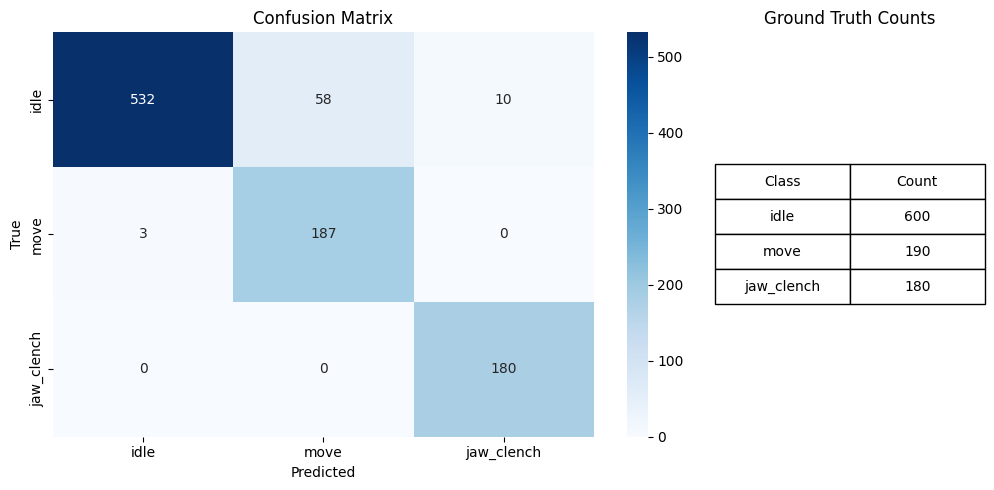

In [44]:
# Run inference on all samples
all_preds = []
all_labels = []

for x, label in zip(X, y):
    out = inference(model=MODEL, x=x, device=DEVICE)
    predicted_index = out.argmax(dim=1).item()
    all_preds.append(predicted_index)
    all_labels.append(label)

# Metrics
class_names = list(LABEL_MAP.keys())

accuracy = accuracy_score(all_labels, all_preds)
f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
kappa = cohen_kappa_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy:        {accuracy:.4f}")
print(f"F1 (macro):      {f1_macro:.4f}")
print(f"F1 (weighted):   {f1_weighted:.4f}")
print(f"Cohen's Kappa:   {kappa:.4f}")
print()
print("Per-class report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Count per class in ground truth
class_counts = {MAP_LABEL[i]: sum(1 for l in all_labels if l == i) for i in range(len(class_names))}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'width_ratios': [3, 1]})

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix")

# Class counts table
axes[1].axis('off')
table_data = [[cls, count] for cls, count in class_counts.items()]
table = axes[1].table(
    cellText=table_data,
    colLabels=["Class", "Count"],
    loc='center',
    cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 2)
axes[1].set_title("Ground Truth Counts")

plt.tight_layout()
plt.show()